In [1]:
# Step 1: Install kagglehub if not already installed
!pip install -q kagglehub


In [2]:
# Step 2: Import necessary libraries
import kagglehub
import zipfile
import os
from PIL import Image
import matplotlib.pyplot as plt


In [5]:
# Step 3: Download the dataset
path = kagglehub.dataset_download("karakaggle/kaggle-cat-vs-dog-dataset")
print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/kaggle-cat-vs-dog-dataset


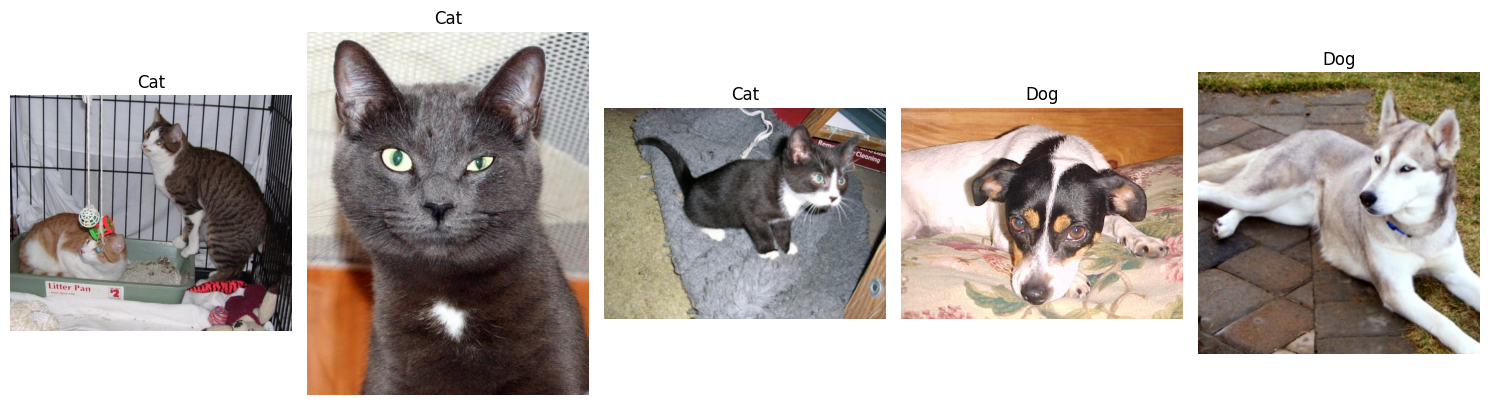

In [6]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Set dataset paths
base_path = "/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages"
cat_path = os.path.join(base_path, "Cat")
dog_path = os.path.join(base_path, "Dog")

# Get valid image paths (some images in this dataset might be corrupt)
def get_valid_images(folder, count):
    valid_images = []
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()  # Check if it's a valid image
            valid_images.append(img_path)
            if len(valid_images) == count:
                break
        except:
            continue
    return valid_images

# Load 3 cat and 2 dog images
cat_images = get_valid_images(cat_path, 3)
dog_images = get_valid_images(dog_path, 2)
sample_images = cat_images + dog_images

# Display the images
plt.figure(figsize=(15, 5))
for idx, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(1, 5, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Cat" if "Cat" in img_path else "Dog")
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torchvision.models as models

# Load the pretrained ResNet50 model
resnet50 = models.resnet50(pretrained=True)

# Set to evaluation mode (important if you're not training)
resnet50.eval()

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet50 = resnet50.to(device)

print("ResNet50 model loaded and ready.")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 88.5MB/s]


ResNet50 model loaded and ready.


In [ ]:
import torch
import torch.nn.functional as F
import torchvision.models as models

# Load pretrained model
resnet50 = models.resnet50(pretrained=True)
resnet50.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet50 = resnet50.to(device)

# Choose the target convolutional layer
target_layer = resnet50.layer4[-1].conv3

# Storage for features and gradients
feature_maps = {}
gradients = {}

# Forward hook: save the feature maps
def forward_hook(module, input, output):
    feature_maps['value'] = output.detach()

# Backward hook: save gradients w.r.t. feature maps
def backward_hook(module, grad_input, grad_output):
    gradients['value'] = grad_output[0].detach()

# Register hooks
forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_backward_hook(backward_hook)


In [ ]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import os

# 1. Load a sample image from your dataset
img_path = "/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages/Cat/0.jpg"  # Replace with valid path

# 2. Preprocess the image (Resize → ToTensor → Normalize)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])

# Load image and apply preprocessing
image = Image.open(img_path).convert("RGB")
input_tensor = preprocess(image).unsqueeze(0).to(device)  # Shape: [1, 3, 224, 224]

# 3. Forward pass
output = resnet50(input_tensor)

# 4. Choose target class (e.g., class with highest score)
target_class = output.argmax(dim=1).item()

# 5. Zero gradients and backward pass
resnet50.zero_grad()
class_score = output[0, target_class]
class_score.backward()


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [ ]:
import os
from PIL import Image
from torchvision import transforms
import torch

# Set path to PetImages folder
cat_dir = "/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages/Cat"

# Find the first valid image
def get_first_valid_image(directory):
    for filename in os.listdir(directory):
        path = os.path.join(directory, filename)
        try:
            with Image.open(path) as img:
                img.verify()  # Validate image
            return path
        except:
            continue
    raise Exception("No valid images found.")

# Get a valid image path
img_path = get_first_valid_image(cat_dir)

# Load and preprocess the image
image = Image.open(img_path).convert("RGB")
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
input_tensor = preprocess(image).unsqueeze(0).to(device)  # Shape: [1, 3, 224, 224]

# Forward and backward pass for Grad-CAM
output = resnet50(input_tensor)
target_class = output.argmax(dim=1).item()
resnet50.zero_grad()
output[0, target_class].backward()

print(f"Used image: {img_path}")
print(f"Target class index: {target_class}")



Used image: /kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages/Cat/7981.jpg
Target class index: 282


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# 1. Get stored feature maps and gradients
features = feature_maps['value']          # Shape: [1, C, H, W]
grads = gradients['value']                # Shape: [1, C, H, W]

# 2. Global Average Pooling on gradients to get alpha_k^c
weights = torch.mean(grads, dim=(2, 3))   # Shape: [1, C]

# 3. Weight the channels in the feature map
gcam = torch.sum(weights[:, :, None, None] * features, dim=1)  # Shape: [1, H, W]

# 4. Apply ReLU
gcam = F.relu(gcam)

# 5. Normalize to [0, 1] for visualization
gcam -= gcam.min()
gcam /= gcam.max()
heatmap = gcam.squeeze().cpu().numpy()   # Shape: [H, W]


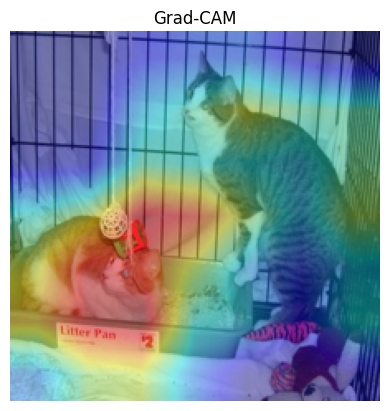

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Resize heatmap to match image size (224x224)
heatmap_resized = cv2.resize(heatmap, (224, 224))  # shape: [224, 224]

# 2. Convert heatmap to color
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# 3. Prepare original image (as numpy)
img_np = np.array(image.resize((224, 224)))  # shape: [224, 224, 3]

# 4. Superimpose heatmap onto image
overlay = heatmap_color * 0.4 + img_np * 0.6
overlay = np.uint8(overlay)  # Convert to uint8 for display

# 5. Display
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM")
plt.show()


<ipython-input-22-a7809f4351e8>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  heatmap_tensor = torch.tensor(gcam).unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]


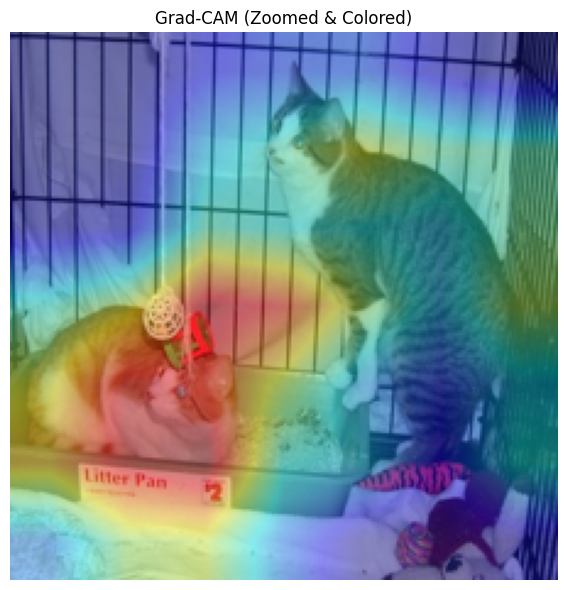

In [ ]:
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Ensure gcam is [H, W]
if gcam.ndim == 3:
    gcam = gcam.squeeze(0)  # From [1, H, W] to [H, W]

# 1. Convert to tensor and upsample to [224, 224]
heatmap_tensor = torch.tensor(gcam).unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
upsampled = F.interpolate(heatmap_tensor, size=(224, 224), mode='bilinear', align_corners=False)
heatmap = upsampled.squeeze().cpu().numpy()  # [224, 224]

# 2. Normalize heatmap to [0, 255]
heatmap -= heatmap.min()
heatmap /= heatmap.max()
heatmap_uint8 = np.uint8(255 * heatmap)

# 3. Convert to JET color map
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# 4. Prepare original image
original_image = np.array(image.resize((224, 224)))

# 5. Blend the heatmap with the image
combined = 0.4 * heatmap_color + 0.6 * original_image
combined = np.uint8(combined)

# 6. Display
plt.figure(figsize=(6, 6))
plt.imshow(combined)
plt.axis('off')
plt.title("Grad-CAM (Zoomed & Colored)")
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn

class GuidedReLU(nn.Module):
    def forward(self, input):
        return torch.relu(input)

    def backward(self, grad_output):
        # Positive grad_output and positive input → pass
        grad_input = grad_output.clone()
        grad_input[grad_output < 0] = 0
        return grad_input


In [ ]:
# Hook storage
gb_gradients = []

def relu_backward_hook(module, grad_input, grad_output):
    # block negative gradients
    return tuple(torch.clamp(g, min=0.0) for g in grad_input)

def register_guided_backprop_hooks(model):
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            module.register_backward_hook(relu_backward_hook)


In [ ]:
register_guided_backprop_hooks(resnet50)

In [ ]:
# Clone input and enable gradient tracking
guided_input = input_tensor.clone().detach().requires_grad_(True)

# Forward pass
guided_output = resnet50(guided_input)

# Target class score
target_score = guided_output[0, target_class]

# Zero gradients and backpropagate
resnet50.zero_grad()
target_score.backward()

# Guided backprop result is the gradient wrt the input
guided_grad = guided_input.grad.detach().cpu().squeeze().numpy()  # shape: [3, 224, 224]


In [ ]:
# Transpose to HWC
guided_rgb = np.transpose(guided_grad, (1, 2, 0))  # [224, 224, 3]

# Normalize for visualization
guided_rgb -= guided_rgb.min()
guided_rgb /= guided_rgb.max()
guided_rgb = np.uint8(255 * guided_rgb)


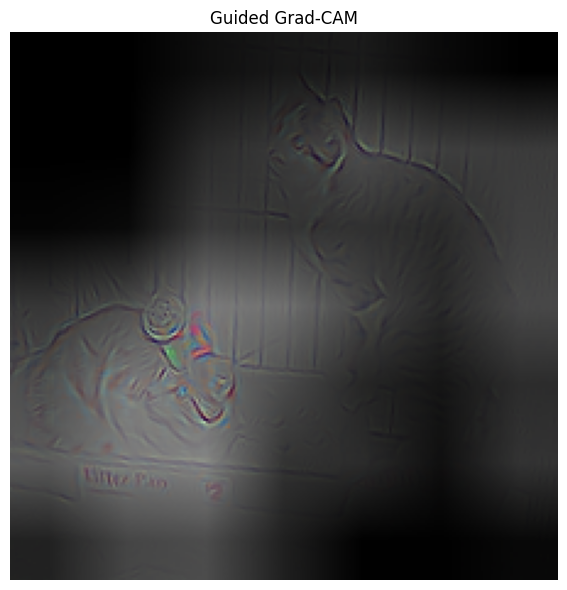

In [ ]:
# Resize Grad-CAM (224, 224) → match guided_rgb
gradcam_mask = heatmap[..., np.newaxis]  # [224, 224, 1]

# Multiply guided backprop and heatmap
guided_gradcam = guided_rgb * gradcam_mask
guided_gradcam = np.uint8(guided_gradcam)

# Show result
plt.figure(figsize=(6, 6))
plt.imshow(guided_gradcam)
plt.axis('off')
plt.title("Guided Grad-CAM")
plt.tight_layout()
plt.show()


In [ ]:
feature_maps = {}
gradients = {}

def forward_hook(module, input, output):
    feature_maps['value'] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradients['value'] = grad_output[0].detach()

# Attach to target conv layer
target_layer = resnet50.layer4[-1].conv3
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)


In [ ]:
def relu_backward_hook(module, grad_input, grad_output):
    return tuple(torch.clamp(g, min=0.0) for g in grad_input)

def register_guided_backprop_hooks(model):
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            module.register_backward_hook(relu_backward_hook)

register_guided_backprop_hooks(resnet50)


In [ ]:
def process_image(img_path):
    # --- Load & preprocess
    image = Image.open(img_path).convert("RGB")
    img_for_display = image.resize((224, 224))
    input_tensor = preprocess(image).unsqueeze(0).to(device).requires_grad_(True)

    # --- Forward
    output = resnet50(input_tensor)
    target_class = output.argmax(dim=1).item()

    # --- Backward
    resnet50.zero_grad()
    output[0, target_class].backward()

    # --- Grad-CAM
    fmap = feature_maps['value']
    grads = gradients['value']
    weights = torch.mean(grads, dim=(2, 3))
    gcam = torch.sum(weights[:, :, None, None] * fmap, dim=1)
    gcam = F.relu(gcam)
    gcam = F.interpolate(gcam.unsqueeze(1), size=(224, 224), mode='bilinear', align_corners=False)
    heatmap = gcam.squeeze().cpu().numpy()
    heatmap -= heatmap.min()
    heatmap /= heatmap.max()
    heatmap_uint8 = np.uint8(255 * heatmap)
    gcam_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    gcam_colored = cv2.cvtColor(gcam_colored, cv2.COLOR_BGR2RGB)

    # --- Guided Backprop
    gb = input_tensor.grad.squeeze().cpu().numpy()
    gb = np.transpose(gb, (1, 2, 0))
    gb -= gb.min()
    gb /= gb.max()
    gb = np.uint8(255 * gb)

    # --- Guided Grad-CAM
    gcam_mask = heatmap[..., np.newaxis]
    guided_gradcam = np.uint8(gb * gcam_mask)

    return np.array(img_for_display), gcam_colored, gb, guided_gradcam


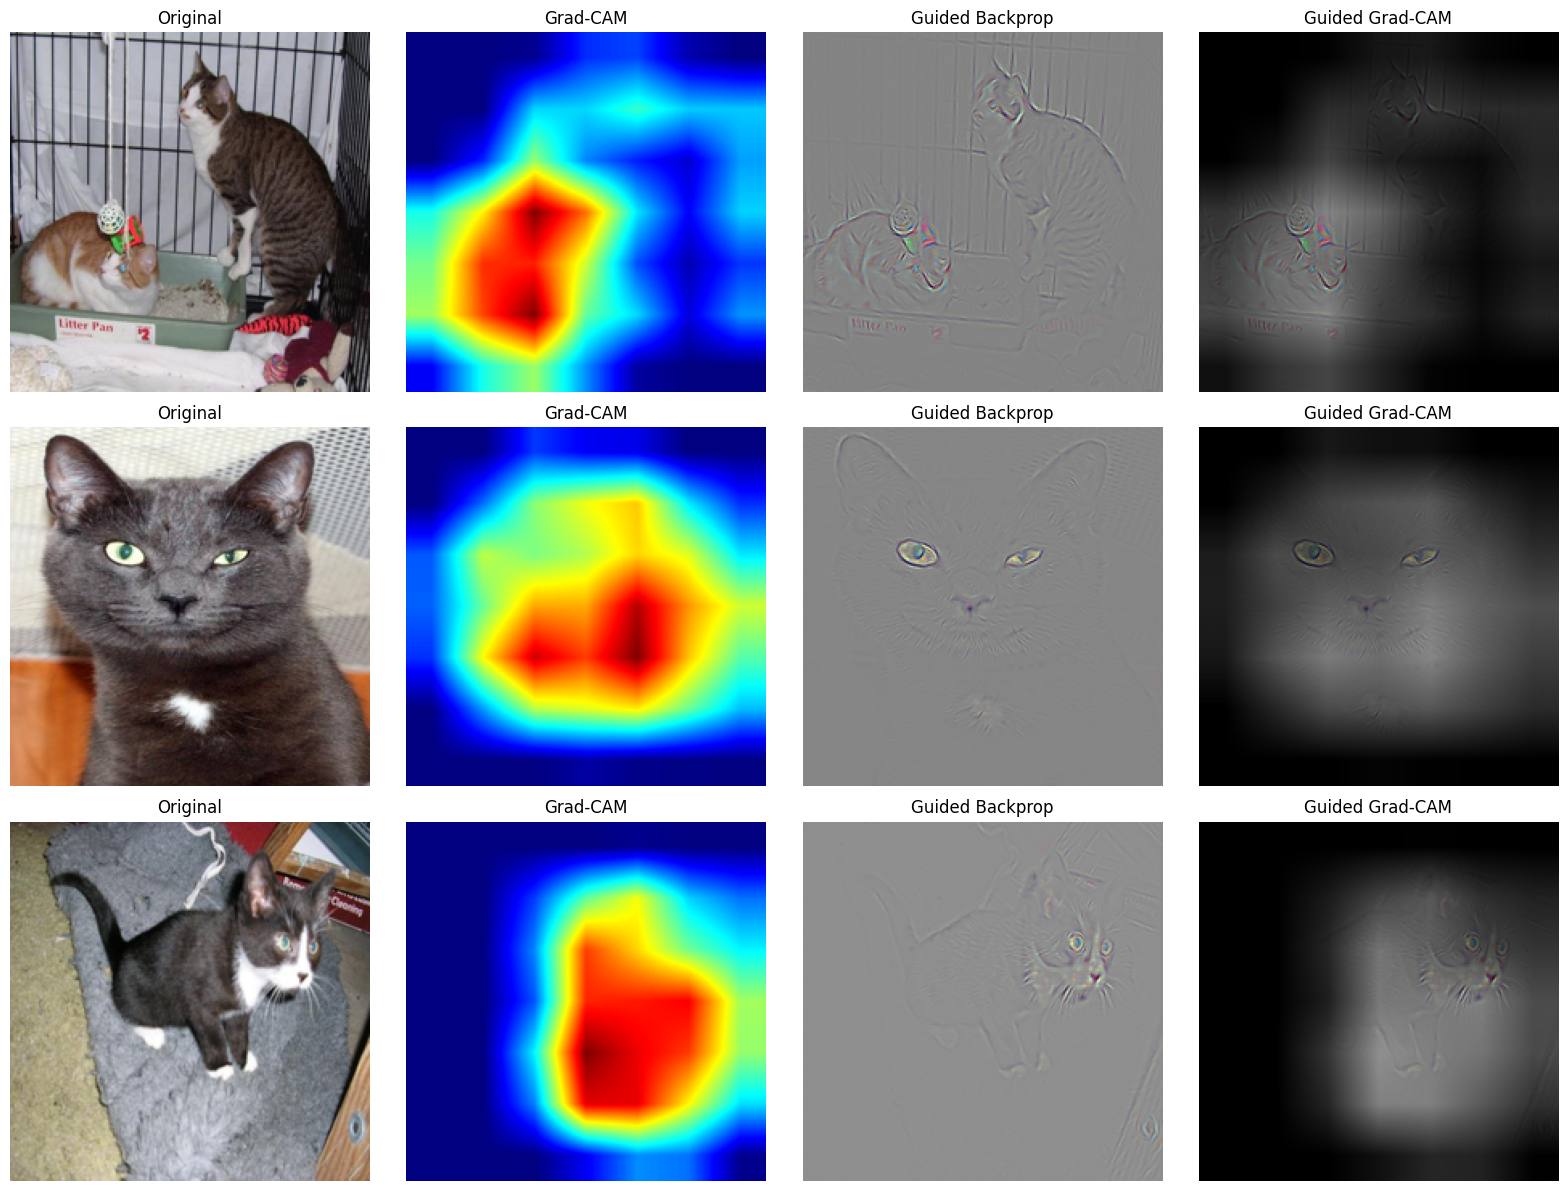

In [ ]:
# Choose a few valid image paths (you can automate this)
cat_dir = "/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages/Cat"
img_list = [os.path.join(cat_dir, f) for f in os.listdir(cat_dir) if f.endswith(".jpg")][:3]

# Run and plot
fig, axes = plt.subplots(len(img_list), 4, figsize=(16, 12))

for row, img_path in enumerate(img_list):
    try:
        original, gradcam, guided_bp, guided_gcam = process_image(img_path)

        axes[row, 0].imshow(original)
        axes[row, 0].set_title("Original")
        axes[row, 1].imshow(gradcam)
        axes[row, 1].set_title("Grad-CAM")
        axes[row, 2].imshow(guided_bp)
        axes[row, 2].set_title("Guided Backprop")
        axes[row, 3].imshow(guided_gcam)
        axes[row, 3].set_title("Guided Grad-CAM")
    except:
        continue

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
activation = {}

def hook_layer4(module, input, output):
    activation['layer4'] = output.detach()

# Register hook
resnet50.layer4.register_forward_hook(hook_layer4)


In [ ]:
def visualize_feature_maps(img_path, num_channels=6):
    # Load image
    image = Image.open(img_path).convert("RGB")
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Forward pass
    _ = resnet50(input_tensor)

    # Get feature map from layer4
    fmap = activation['layer4'].squeeze(0).cpu()  # Shape: [C, H, W]

    # Select a few channels
    selected_channels = torch.linspace(0, fmap.shape[0] - 1, steps=num_channels).long()

    # Plot
    fig, axes = plt.subplots(1, num_channels, figsize=(18, 5))
    for i, ch in enumerate(selected_channels):
        fmap_img = fmap[ch]
        axes[i].imshow(fmap_img, cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f"Channel {ch.item()}")
    plt.suptitle("Feature Maps from layer4")
    plt.tight_layout()
    plt.show()


 Cat Image:


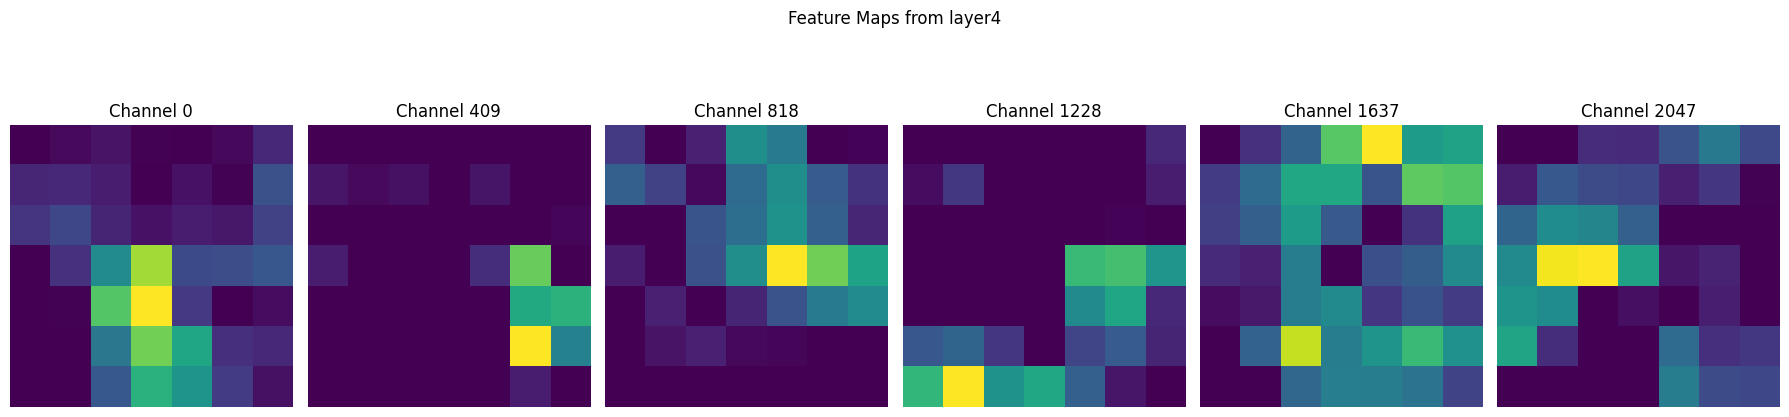

 Dog Image:


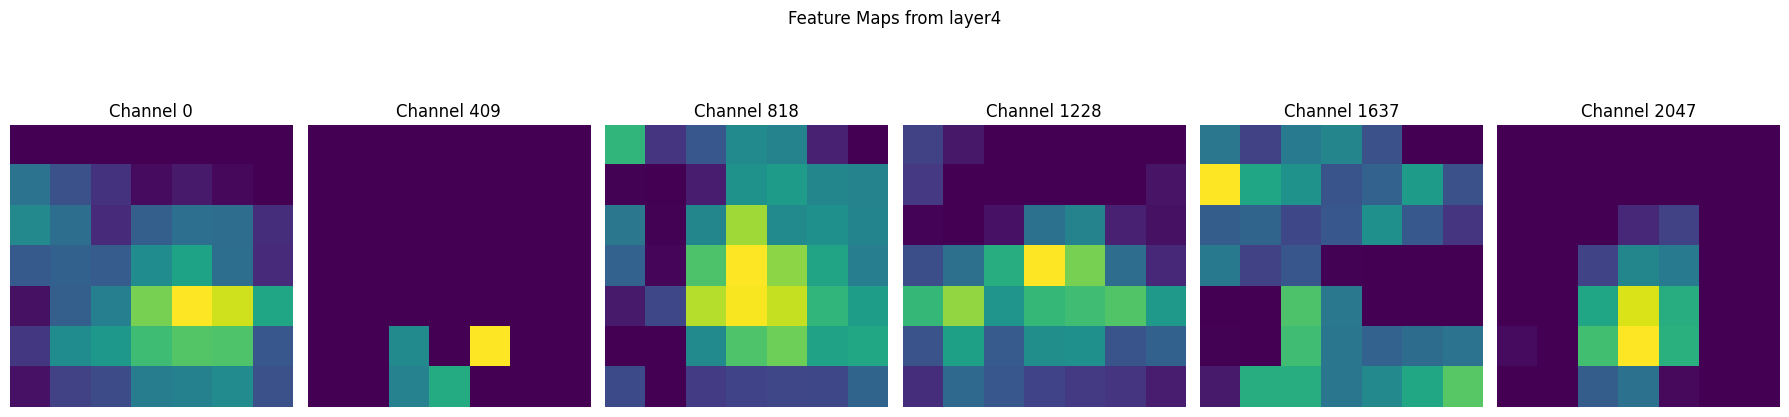

In [ ]:
# Example cat and dog paths (replace with valid ones from your dataset)
cat_dir = "/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages/Cat"
dog_dir = "/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages/Dog"

# Select valid files (non-corrupt)
def get_valid_image(directory):
    for f in os.listdir(directory):
        path = os.path.join(directory, f)
        try:
            Image.open(path).verify()
            return path
        except:
            continue

cat_img = get_valid_image(cat_dir)
dog_img = get_valid_image(dog_dir)

# Run visualization
print(" Cat Image:")
visualize_feature_maps(cat_img)

print(" Dog Image:")
visualize_feature_maps(dog_img)


## Adversary

In [7]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import requests
from io import BytesIO
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained VGG16
vgg16 = models.vgg16(pretrained=True).eval().to(device)

# ImageNet labels
LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_labels = requests.get(LABELS_URL).text.strip().split("\n")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:03<00:00, 158MB/s]


In [8]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def load_image_from_url(url):
    image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    return image, input_tensor


In [11]:
!git clone https://github.com/EliSchwartz/imagenet-sample-images.git

Cloning into 'imagenet-sample-images'...
remote: Enumerating objects: 1012, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 1012 (delta 3), reused 5 (delta 2), pack-reused 1002 (from 1)
Receiving objects: 100% (1012/1012), 103.84 MiB | 13.85 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [12]:
image_paths = [
    "imagenet-sample-images/n01440764_tench.JPEG",
    "imagenet-sample-images/n02124075_Egyptian_cat.JPEG"
]


In [13]:
from PIL import Image
import torch
from torchvision import models, transforms

# Load pretrained VGG16 model
vgg16 = models.vgg16(pretrained=True).eval()

# Define preprocessing steps
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load and preprocess images
images = []
for path in image_paths:
    img = Image.open(path).convert("RGB")
    img_tensor = preprocess(img).unsqueeze(0)
    images.append((img, img_tensor))


In [14]:
# Load ImageNet class labels
import json
import urllib.request

url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
class_idx = []
with urllib.request.urlopen(url) as f:
    class_idx = [line.strip() for line in f.readlines()]

# Predict and print results
for i, (img, img_tensor) in enumerate(images):
    outputs = vgg16(img_tensor)
    _, predicted = outputs.max(1)
    print(f"Image {i+1} predicted as: {class_idx[predicted.item()]}")


Image 1 predicted as: b'tench'
Image 2 predicted as: b'Egyptian cat'


In [15]:
feature_maps = {}
gradients = {}

def forward_hook(module, input, output):
    feature_maps['value'] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradients['value'] = grad_output[0].detach()

target_layer = vgg16.features[29]
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

def gradcam_vgg16(input_tensor, orig_img):
    output = vgg16(input_tensor)
    class_idx = output.argmax(dim=1).item()
    class_label = imagenet_labels[class_idx]
    print(f"Predicted: {class_label} (class index {class_idx})")

    # Backward pass for target class
    vgg16.zero_grad()
    output[0, class_idx].backward()

    # Grad-CAM computation
    fmap = feature_maps['value']        # shape: [1, C, H, W]
    grads = gradients['value']          # shape: [1, C, H, W]
    weights = grads.mean(dim=(2, 3))    # shape: [1, C]

    cam = (weights[:, :, None, None] * fmap).sum(dim=1)
    cam = F.relu(cam)
    cam = F.interpolate(cam.unsqueeze(1), size=(224, 224), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()

    # Normalize heatmap
    cam -= cam.min()
    cam /= cam.max()
    cam = np.uint8(255 * cam)

    # Overlay heatmap
    heatmap = cv2.applyColorMap(cam, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    orig_img = np.array(orig_img.resize((224, 224)))
    overlay = np.uint8(0.4 * heatmap + 0.6 * orig_img)

    # Show
    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(f"Grad-CAM: {class_label}")
    plt.show()


In [19]:
vgg16 = vgg16.to(device)  # device = 'cuda' if available

In [20]:
# Global hook storage
feature_maps = {}
gradients = {}

def forward_hook(module, input, output):
    feature_maps['value'] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradients['value'] = grad_output[0].detach()

# Register hook on last conv layer of VGG16
target_layer = vgg16.features[29]
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)



▶ Grad-CAM for Image 1:


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Predicted: tench (class index 0)


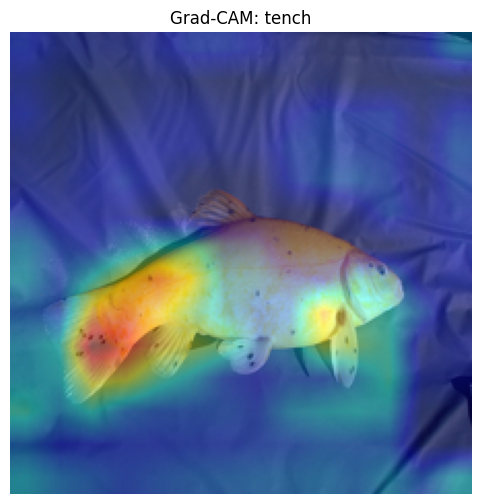


▶ Grad-CAM for Image 2:
Predicted: Egyptian cat (class index 285)


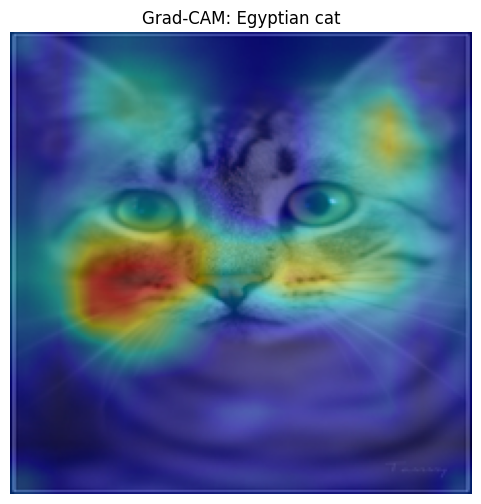

In [21]:
# Reuse the existing preprocessed image tensors
for i, (img_pil, img_tensor) in enumerate(images):
    print(f"\n▶ Grad-CAM for Image {i+1}:")
    gradcam_vgg16(img_tensor.to(device), img_pil)


### PGD Attack Function (Untargeted)

In [22]:
def pgd_attack(model, images, labels, epsilon, alpha=1e-2, iters=10):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    ori_images = images.clone().detach()

    for i in range(iters):
        images.requires_grad = True
        outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        adv_images = images + alpha * images.grad.sign()
        eta = torch.clamp(adv_images - ori_images, min=-epsilon, max=epsilon)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach()

    return images


In [23]:
# Reuse your already-loaded and correctly classified images
attack_epsilons = [0.01, 0.08, 0.15]

# Prepare image tensors and labels
clean_imgs = [img_tensor.to(device) for _, img_tensor in images]
labels = [vgg16(img).argmax(dim=1) for img in clean_imgs]  # Get correct class


In [24]:
def show_adversarial_results(image_pil, original_tensor, label, epsilons):
    original_image = np.array(image_pil.resize((224, 224)))

    fig, axes = plt.subplots(1, len(epsilons) + 1, figsize=(15, 4))
    axes[0].imshow(original_image)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i, eps in enumerate(epsilons):
        adv_img = pgd_attack(vgg16, original_tensor.clone(), label, epsilon=eps)
        output = vgg16(adv_img)
        pred_idx = output.argmax(dim=1).item()
        pred_class = imagenet_labels[pred_idx]

        adv_np = adv_img.squeeze().detach().cpu().permute(1, 2, 0).numpy()
        adv_np = adv_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        adv_np = np.clip(adv_np, 0, 1)

        axes[i + 1].imshow(adv_np)
        axes[i + 1].set_title(f"ε={eps}\n→ {pred_class}")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()



 PGD attack on Image 1


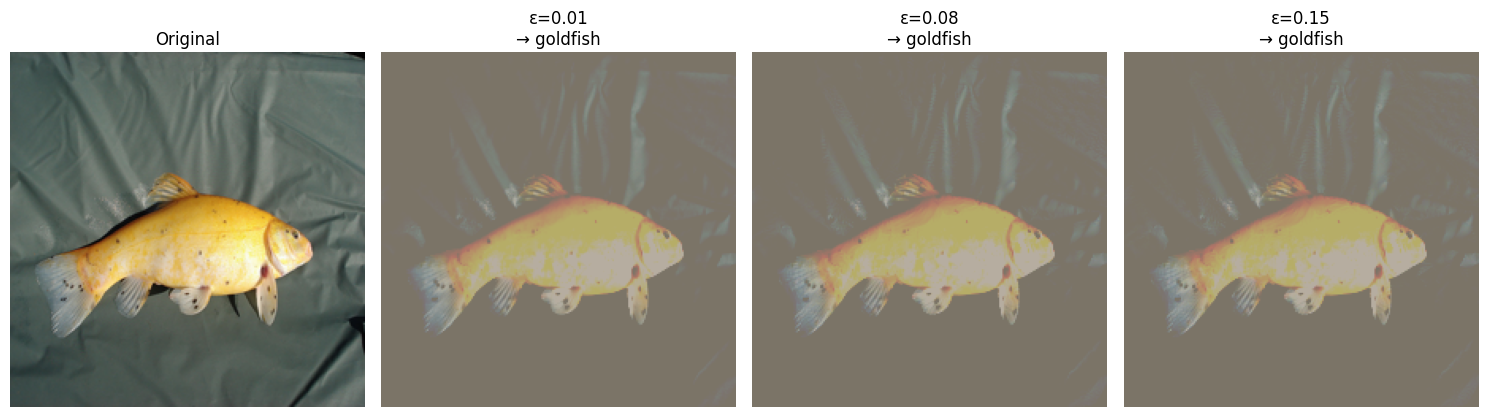


 PGD attack on Image 2


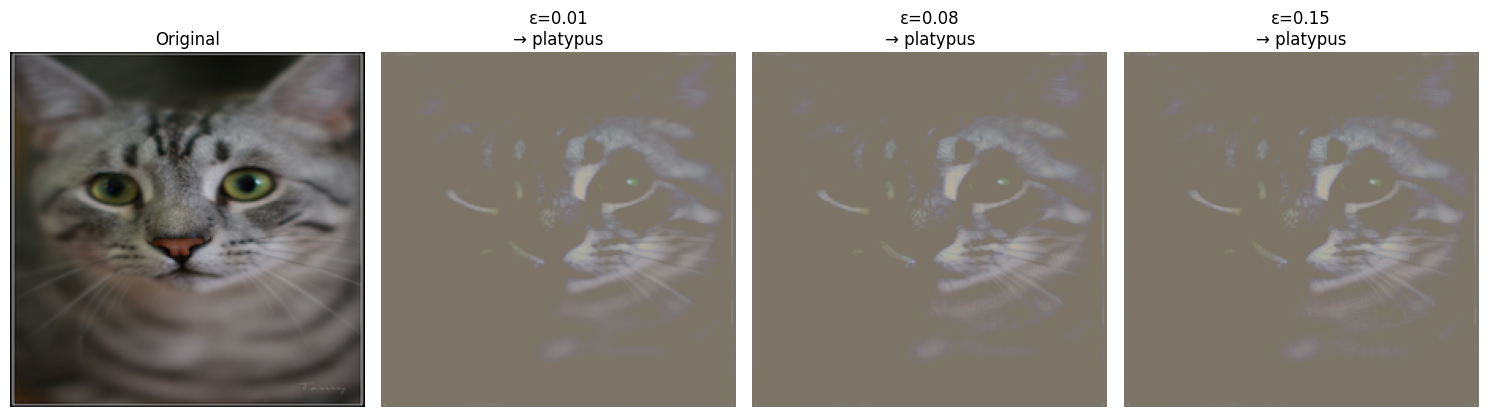

In [26]:
for i in range(2):
    print(f"\n PGD attack on Image {i+1}")
    show_adversarial_results(images[i][0], clean_imgs[i], labels[i], attack_epsilons)


In [27]:
def gradcam_vgg16(input_tensor, image_pil, target_class=None, title_prefix=""):
    input_tensor = input_tensor.to(device)
    output = vgg16(input_tensor)

    if target_class is None:
        class_idx = output.argmax(dim=1).item()
    else:
        class_idx = target_class

    class_label = imagenet_labels[class_idx]
    vgg16.zero_grad()
    output[0, class_idx].backward()

    # Grad-CAM
    fmap = feature_maps['value']
    grads = gradients['value']
    weights = grads.mean(dim=(2, 3))
    cam = (weights[:, :, None, None] * fmap).sum(dim=1)
    cam = F.relu(cam)
    cam = F.interpolate(cam.unsqueeze(1), size=(224, 224), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam -= cam.min()
    cam /= cam.max()
    cam = np.uint8(255 * cam)

    # Overlay
    heatmap = cv2.applyColorMap(cam, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    original = np.array(image_pil.resize((224, 224)))
    overlay = np.uint8(0.4 * heatmap + 0.6 * original)

    plt.imshow(overlay)
    plt.axis("off")
    plt.title(f"{title_prefix}\nClass: {class_label}")


In [28]:
def show_gradcams_for_adversarial(image_pil, orig_tensor, orig_class_idx, epsilons):
    fig, axes = plt.subplots(len(epsilons), 2, figsize=(10, 3 * len(epsilons)))

    for i, eps in enumerate(epsilons):
        # Generate adversarial image
        adv_tensor = pgd_attack(vgg16, orig_tensor.clone(), torch.tensor([orig_class_idx]), epsilon=eps)
        output = vgg16(adv_tensor)
        pred_class = output.argmax(dim=1).item()

        # Grad-CAM for predicted class
        plt.subplot(len(epsilons), 2, 2 * i + 1)
        gradcam_vgg16(adv_tensor, image_pil, target_class=pred_class,
                      title_prefix=f"ε={eps} — Predicted")

        # Grad-CAM for original class
        plt.subplot(len(epsilons), 2, 2 * i + 2)
        gradcam_vgg16(adv_tensor, image_pil, target_class=orig_class_idx,
                      title_prefix=f"ε={eps} — Original")

    plt.tight_layout()
    plt.show()



 Grad-CAM for adversarial versions of Image 1


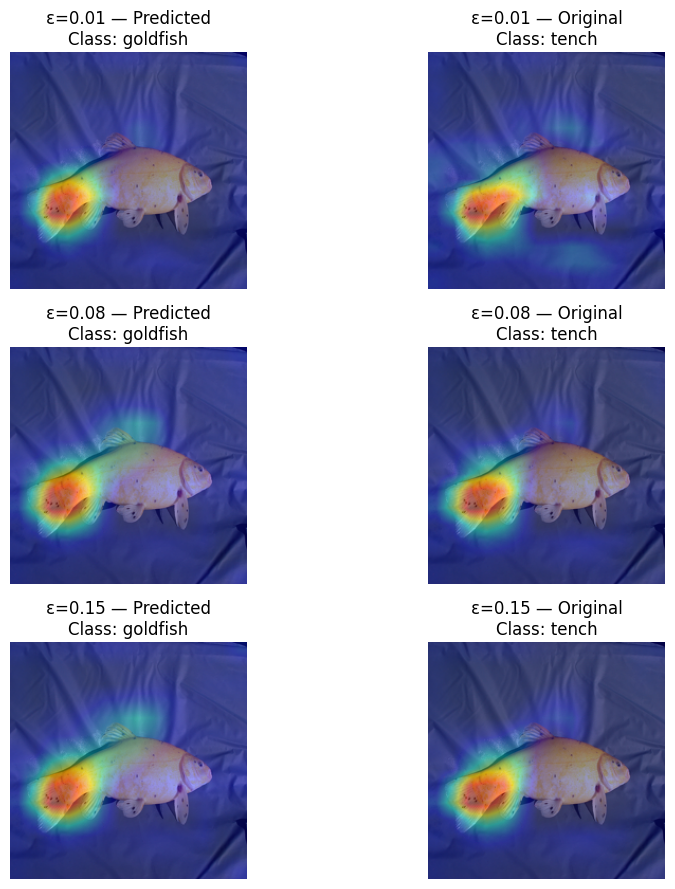


 Grad-CAM for adversarial versions of Image 2


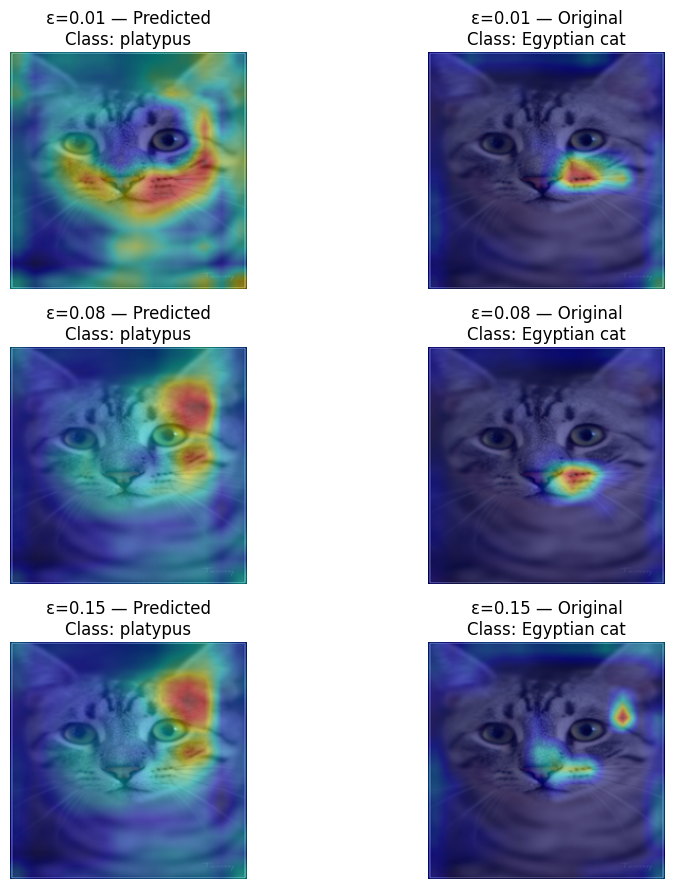

In [29]:
for i in range(2):
    print(f"\n Grad-CAM for adversarial versions of Image {i+1}")
    show_gradcams_for_adversarial(
        image_pil=images[i][0],
        orig_tensor=images[i][1].to(device),
        orig_class_idx=labels[i].item(),
        epsilons=attack_epsilons
    )


### Class Feature Visualization

In [30]:
import torch
import torch.nn.functional as F
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

# Load VGG16
vgg16 = models.vgg16(pretrained=True).eval().to(device)

# Target class index for "Tiger"
target_class = 293


In [31]:
# Random image with gradients enabled
input_img = torch.randn((1, 3, 224, 224), device=device, requires_grad=True)


In [32]:
optimizer = torch.optim.Adam([input_img], lr=0.05)

for i in range(200):
    optimizer.zero_grad()

    # Forward pass
    output = vgg16(input_img)

    # Loss: maximize logit for target class
    loss = -output[0, target_class]  # negative to maximize

    # Optional regularization (L2 norm + total variation)
    loss += 1e-4 * input_img.norm()  # L2 penalty

    loss.backward()
    optimizer.step()

    # Clamp image to keep values within range
    with torch.no_grad():
        input_img.clamp_(-1.5, 1.5)  # image space range


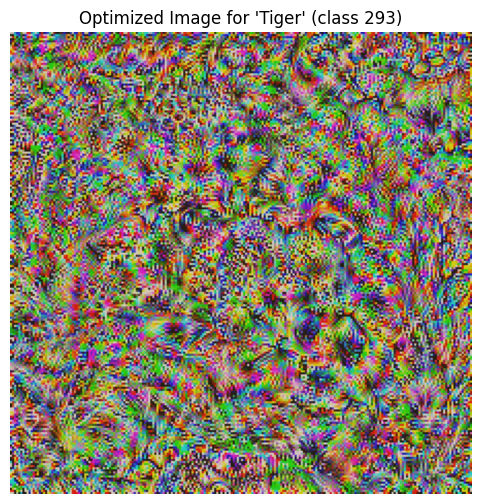

In [34]:
# De-normalize using ImageNet mean/std
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)

img_np = input_img.squeeze().detach()
img_np = img_np * std + mean
img_np = torch.clamp(img_np, 0, 1).permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.axis("off")
plt.title("Optimized Image for 'Tiger' (class 293)")
plt.show()


### Optimization Methods

In [35]:
def total_variation(x):
    return torch.sum(torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :])) + \
           torch.sum(torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:]))


In [36]:
def generate_visualization(target_class=293, seed=None, steps=200, lr=0.05, tv_weight=1e-4, jitter=8):
    if seed is not None:
        torch.manual_seed(seed)

    # Start with random noise image
    input_img = torch.randn((1, 3, 224, 224), device=device, requires_grad=True)
    optimizer = torch.optim.Adam([input_img], lr=lr)

    for i in range(steps):
        optimizer.zero_grad()

        # Apply random shift
        ox, oy = torch.randint(-jitter, jitter + 1, (1,)).item(), torch.randint(-jitter, jitter + 1, (1,)).item()
        shifted = torch.roll(input_img, shifts=(ox, oy), dims=(2, 3))

        output = vgg16(shifted)
        loss = -output[0, target_class]  # Maximize class logit

        # Add total variation regularization
        loss += tv_weight * total_variation(shifted)

        loss.backward()
        optimizer.step()

        # Clamp to reasonable range
        with torch.no_grad():
            input_img.clamp_(-1.5, 1.5)

    # De-normalize for display
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)
    img_np = input_img.detach().squeeze()
    img_np = img_np * std + mean
    img_np = torch.clamp(img_np, 0, 1).permute(1, 2, 0).cpu().numpy()
    return img_np


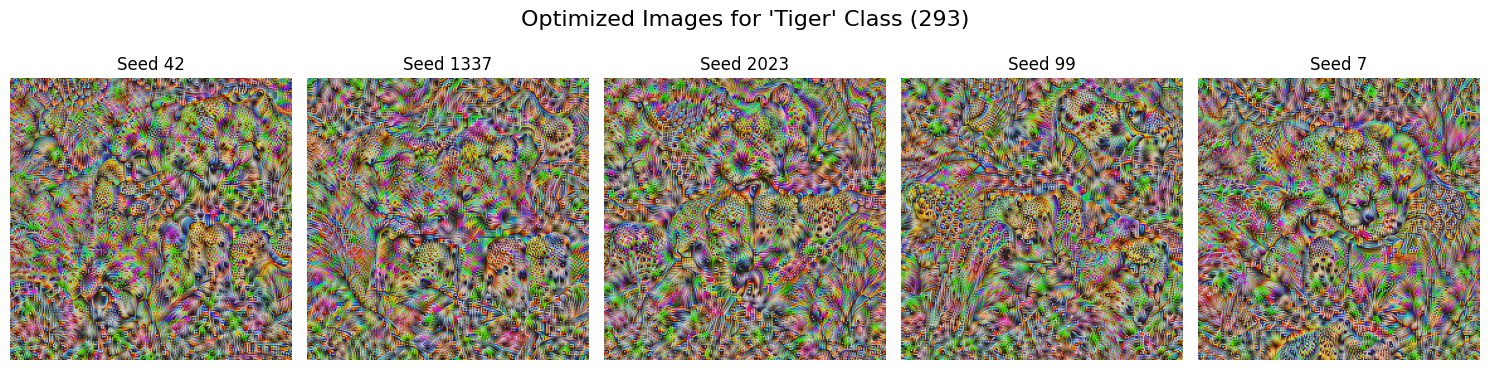

In [37]:
plt.figure(figsize=(15, 4))
for i, seed in enumerate([42, 1337, 2023, 99, 7]):
    img = generate_visualization(seed=seed)
    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Seed {seed}")
plt.suptitle("Optimized Images for 'Tiger' Class (293)", fontsize=16)
plt.tight_layout()
plt.show()
